## Ładowanie danych i bibliotek



In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("piotrstefaskiue/poland-vehicle-license-plate-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'poland-vehicle-license-plate-dataset' dataset.
Path to dataset files: /kaggle/input/poland-vehicle-license-plate-dataset


In [ ]:
!pip install ultralytics easyocr opencv-python-headless lxml gdown
!mkdir dataset
!ln -s /kaggle/input/poland-vehicle-license-plate-dataset dataset
!gdown --id 1WBC1FK6IQFZzwXE16t0Yy7bm6zUTqGns -O plate_model_s.zip
!gdown --id 1hXAbW4glSOwwtQgja6dFYbRxI37-HJMz -O yolo26s.pt
!unzip -n plate_model_s.zip
!rm -rf yolo_dataset

In [ ]:
import cv2
import easyocr
import time
import re
from ultralytics import YOLO
import os
from lxml import etree
import matplotlib.pyplot as plt
import random
import shutil

In [4]:
IMAGES_DIR = 'dataset/poland-vehicle-license-plate-dataset/photos'
XML_PATH = 'dataset/poland-vehicle-license-plate-dataset/annotations.xml'
MODEL_PATH = 'runs/detect/plate_detector_s/weights/best.pt'

usuwanie datasetu YOLO (np. do innego podziału train/val)

In [5]:
!rm -rf yolo_dataset

## Metody do YOLO + OCR

Ładowanie danych z annotations.xml

In [6]:
def load_xml_data(xml_path, images_dir):
  tree = etree.parse(xml_path)
  root = tree.getroot()
  data = []

  for image in root.findall('image'):
    img_name = image.get('name')
    img_path = os.path.join(images_dir, img_name)
    for box in image.findall('box'):
      x1 = int(float(box.get('xtl')))
      y1 = int(float(box.get('ytl')))
      x2 = int(float(box.get('xbr')))
      y2 = int(float(box.get('ybr')))
      plate_text = ''
      for attr in box.findall('attribute'):
        if 'plate' in attr.get('name','').lower():
          plate_text = attr.text.strip() if attr.text else ''
      data.append({
        'image': img_path,
        'bbox': (x1, y1, x2, y2),
        'text': plate_text
      })
  return data[:150]

Metody do Segmentacji + EasyOCR

In [ ]:
reader = easyocr.Reader(['en'], gpu=True)
ALLOWED = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789' # znaki dozwolone na tablicach

def normalize(text: str) -> str:
  # wcześniej było tu więcej formatowania tekstu
  # teraz metoda jest mało potrzebna ale została na wszelki wypadek
  text = text.upper()
  return text

def segmentation_preprocess(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    th = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 7
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    th = cv2.dilate(th, kernel, iterations=1)
    return th

def segment_char_boxes(plate_bgr):
    th = segmentation_preprocess(plate_bgr)
    h, w = th.shape
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x, y, cw, ch = cv2.boundingRect(c)
        # Odrzucanie segmentów
        if ch < 0.45*h:       # zbyt niski
            continue
        if cw < 0.025*w:       # zbyt wąski
            continue
        if cw > 0.30*w:       # zbyt szeroki
            continue
        if y > 0.85*h:        # z dolnej części tablicy
            continue
        boxes.append((x, y, cw, ch))
    boxes = sorted(boxes, key=lambda b: b[0])
    if len(boxes) > 10:
        boxes = boxes[:10]

    return boxes

def ocr_single_char_recognize(img, allowlist=ALLOWED):
  # ocr z wykorzystaniem reader.recognize - chyba działa lepiej niż reader.readtext?
    out = reader.recognize(img, allowlist=allowlist, detail=1, paragraph=False)
    if not out:
        return "?", 0.0
    best_text, best_conf = "?", 0.0
    for item in out:
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            txt, conf = item[1], float(item[2])
        else:
            continue
        txt = normalize(txt)
        if txt and txt[0] in ALLOWED and conf > best_conf:
            best_text, best_conf = txt[0], conf

    return best_text, best_conf

def ocr_single_char(char_bgr):
    pad = 6
    h, w = char_bgr.shape[:2]
    char_bgr = cv2.copyMakeBorder(char_bgr, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=(255,255,255))

    gray = cv2.cvtColor(char_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=3.0, fy=3.0, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    ch, conf = ocr_single_char_recognize(th)
    return ch if ch else "?" # zwraca '?' jeśli nie rozpozna znaku

def pl_postprocess(text):
    # podmiana cyfr na znaki, jeśli są to pierwsze 2 znaki (dobre dla polskich tablic)
    t = list(normalize(text))
    if len(t) < 6:
        return "".join(t)

    letter_zone = set([0, 1])
    for i, ch in enumerate(t):
        if i in letter_zone:
            t[i] = {"0":"O", "1":"I", "5":"S", "6":"G", "2": "Z", "4": "A", "7": "Z"}.get(ch, ch)

    return "".join(t)

def ocr_plate_segmented(plate_bgr, debug=False):
    h, w, _ = plate_bgr.shape
    plate = plate_bgr[:, int(0.10*w):]  # ucinanie niebieskiego paska z krajem
    boxes = segment_char_boxes(plate)

    if debug: # wyświetlanie segmentów, jeśli debug jest włączony
        dbg = plate.copy()
        for (x,y,cw,ch) in boxes:
            cv2.rectangle(dbg, (x,y), (x+cw, y+ch), (0,255,0), 2)
        plt.figure(figsize=(10,3))
        plt.title(f"Segments found: {len(boxes)}")
        plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    chars = []
    for (x,y,cw,ch) in boxes:
      char_crop = plate[y:y+ch, x:x+cw]
      ch_text = ocr_single_char(char_crop)
      chars.append(ch_text)

    pred = "".join(chars)
    pred = normalize(pred)
    pred = pl_postprocess(pred)

    return pred

# tylko do wyświetlania liter przekazywanych do OCR
def show_char_ocr(plate_bgr, cut_left_pct=0.10, max_chars=12):
    h, w = plate_bgr.shape[:2]
    plate = plate_bgr[:, int(cut_left_pct*w):]

    boxes = segment_char_boxes(plate)
    n = min(len(boxes), max_chars)
    if n == 0:
        print("Brak segmentów.")
        return

    plt.figure(figsize=(2.2*n, 6))

    for i, (x,y,cw,ch) in enumerate(boxes[:n]):
        char_bgr = plate[y:y+ch, x:x+cw]
        pad = 8
        char_pad = cv2.copyMakeBorder(char_bgr, pad, pad, pad, pad,
                                      cv2.BORDER_CONSTANT, value=(255,255,255))
        gray = cv2.cvtColor(char_pad, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=3.0, fy=3.0, interpolation=cv2.INTER_CUBIC)
        gray = cv2.GaussianBlur(gray, (3,3), 0)
        th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

        results = reader.readtext(th, allowlist=ALLOWED, detail=1, paragraph=False)
        if results:
            best = max(results, key=lambda x: x[2])
            pred = normalize(best[1])[:1] if best[1] else "?"
            conf = float(best[2])
        else:
            pred, conf = "?", 0.0

        plt.subplot(2, n, n + i + 1)
        plt.imshow(th, cmap="gray")
        plt.title(pred)
        plt.axis("off")

    plt.tight_layout()
    plt.show()




## Budowanie datasetu YOLO, pokazanie wyników

### Logika programu

Budowanie datasetu, podział train/val, tworzenie pliku .yaml

In [10]:
YOLO_DIR = 'yolo_dataset'
TRAIN_RATIO = 0.7

os.makedirs(YOLO_DIR, exist_ok=True)
os.makedirs(os.path.join(YOLO_DIR, 'train/images'), exist_ok=True)
os.makedirs(os.path.join(YOLO_DIR, 'train/labels'), exist_ok=True)
os.makedirs(os.path.join(YOLO_DIR, 'val/images'), exist_ok=True)
os.makedirs(os.path.join(YOLO_DIR, 'val/labels'), exist_ok=True)

tree = etree.parse(XML_PATH)
root = tree.getroot()
random.seed(3)
data = []
for image in root.findall('image'):
    img_name = image.get('name')
    img_path = os.path.join(IMAGES_DIR, img_name)
    width = int(image.get('width', 1280))
    height = int(image.get('height', 720))

    for box in image.findall('box'):
        x1 = float(box.get('xtl'))
        y1 = float(box.get('ytl'))
        x2 = float(box.get('xbr'))
        y2 = float(box.get('ybr'))
        data.append({'image': img_path, 'width': width, 'height': height, 'bbox': (x1,y1,x2,y2)})

random.shuffle(data)
split_idx = int(len(data)*TRAIN_RATIO)
train_data = data[:split_idx]
val_data = data[split_idx:]

def save_yolo_label(entry, label_path):
    x1, y1, x2, y2 = entry['bbox']
    img_w, img_h = entry['width'], entry['height']

    x_center = (x1 + x2)/2 / img_w
    y_center = (y1 + y2)/2 / img_h
    w = (x2 - x1)/img_w
    h = (y2 - y1)/img_h

    with open(label_path, 'w') as f:
        f.write(f"0 {x_center} {y_center} {w} {h}\n")

for dataset, folder in [(train_data, 'train'), (val_data, 'val')]:
    for entry in dataset:
        img_name = os.path.basename(entry['image'])
        dst_img = os.path.join(YOLO_DIR, folder, 'images', img_name)
        dst_label = os.path.join(YOLO_DIR, folder, 'labels', os.path.splitext(img_name)[0]+'.txt')

        shutil.copy(entry['image'], dst_img)
        save_yolo_label(entry, dst_label)

plate_yaml = os.path.join(YOLO_DIR, 'plate.yaml')
with open(plate_yaml, 'w') as f:
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names: ['plate']\n")


Trenowanie YOLO od zera (niepotrzebne bo jest pobierany wytrenowany model)

In [11]:
#model = YOLO('yolo26s.pt') # ultralight model
#model.train(data='yolo_dataset/plate.yaml', epochs=50, batch=4, imgsz=1048, name='plate_detector_s')

Obliczanie oceny

In [12]:
def calculate_final_grade(accuracy_percent: float, processing_time_sec: float) -> float:
  # Check minimum requirements
  if accuracy_percent < 60 or processing_time_sec > 60:
    return 2.0
  # Normalize accuracy: 60% → 0.0, 100% → 1.0
  accuracy_norm = (accuracy_percent - 60) / 40
  # Normalize time: 60s → 0.0, 10s → 1.0
  time_norm = (60 - processing_time_sec) / 50
  # Compute weighted score
  score = 0.7 * accuracy_norm + 0.3 * time_norm

  grade = 2.0 + 3.0 * score
  # Round to the nearest 0.5
  return round(grade * 2) / 2

Uruchamianie procesów YOLO, cropowania, segmentacji i EasyOCR

In [13]:
def evaluate():
  all_data = load_xml_data(XML_PATH, IMAGES_DIR)
  data = random.sample(all_data, k=100) # 100 zdjęć
  model = YOLO(MODEL_PATH) # wytrenowany YOLO (yolo26s)

  correct = 0
  start = time.time()

  for i, sample in enumerate(data, 1):
    img = cv2.imread(sample['image'])
    if img is None:
      continue
    results = model.predict(img, verbose=False) # YOLO
    if len(results) == 0 or len(results[0].boxes) == 0:
      continue

    box = results[0].boxes[0].xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = box
    crop = img[y1:y2, x1:x2] # przycinanie do wykrytej tablicy
    if crop.size == 0:
      print("empty crop")
      continue

    pred_text = ocr_plate_segmented(crop, debug=False) # segmentacja + ocr znaków
    gt_text = normalize(sample['text'])
    fname = os.path.basename(sample['image'])
    print(f"[Image {fname}] Predicted: '{pred_text}' \t Real: '{gt_text}' \t\t", end="")
    if pred_text != gt_text:
      print("Incorrect")
    else:
      print("Correct")
      correct += 1

  elapsed = time.time() - start
  accuracy = correct / len(data) * 100

  print(f'Accuracy OCR: {accuracy:.2f}%')
  print(f'Time (100 images): {elapsed:.2f}s')
  print(f'Grade: {calculate_final_grade(accuracy,elapsed)}')

### Wyniki

In [14]:
if __name__ == '__main__':
    evaluate()

[Image 120.jpg] Predicted: '' 	 Real: 'SM79962' 		Incorrect
[Image 122.jpg] Predicted: 'KTTRJ07' 	 Real: 'KTTRJ07' 		Correct
[Image 172.jpg] Predicted: 'SZA7964E' 	 Real: 'SZA7964E' 		Correct
[Image 175.jpg] Predicted: 'SK440AY' 	 Real: 'SK440AY' 		Correct
[Image 15.jpg] Predicted: 'IOS89001' 	 Real: 'KOS8900E' 		Incorrect
[Image 24.jpg] Predicted: '' 	 Real: 'KR3UH61' 		Incorrect
[Image 138.jpg] Predicted: 'SZ099CK' 	 Real: 'SZO99CK' 		Incorrect
[Image 117.jpg] Predicted: 'SK8843W' 	 Real: 'SK8843W' 		Correct
[Image 176.jpg] Predicted: 'ST7736G' 	 Real: 'ST7736G' 		Correct
[Image 148.jpg] Predicted: 'SO68659' 	 Real: 'SO68659' 		Correct
[Image 27.jpg] Predicted: 'OI002LL1' 	 Real: 'STA0211F' 		Incorrect
[Image 160.jpg] Predicted: 'SC3222P' 	 Real: 'SC3222P' 		Correct
[Image 54.jpg] Predicted: 'SO011321' 	 Real: 'SZY71327' 		Incorrect
[Image 126.jpg] Predicted: 'SJ7749E' 	 Real: 'SJ7749E' 		Correct
[Image 106.jpg] Predicted: 'SH9264A' 	 Real: 'SH9264A' 		Correct
[Image 142.jpg] Predict

Miara Intersection over Union (IoU) dla wykorzystanego YOLO

In [44]:
from torch import tensor
from ultralytics.utils.metrics import box_iou

model = YOLO(MODEL_PATH)
tree = etree.parse(XML_PATH)
root = tree.getroot()
iou_sum = 0
nr_img = 0
nr_misses = 0
hits = 0

for img_name in os.listdir("yolo_dataset/val/images"):
  nr_img += 1
  img_path = os.path.join("yolo_dataset/val/images", img_name)
  results = model(img_path)
  if results[0].boxes is None or len(results[0].boxes) == 0:
    print("IoU Score = 0.0")
    nr_misses += 1
    continue
  pred_box = tensor(results[0].boxes[0].xyxy[0].cpu().numpy()).unsqueeze(0)

  xml_img = root.find(f".//image[@name='{img_name}']")
  correct_box = xml_img.find(".//box[@label='plate']")
  xtl = float(correct_box.get("xtl"))
  ytl = float(correct_box.get("ytl"))
  xbr = float(correct_box.get("xbr"))
  ybr = float(correct_box.get("ybr"))

  correct_vals = tensor([xtl, ytl, xbr, ybr]).unsqueeze(0)
  iou = box_iou(correct_vals, pred_box)
  print(f"[{img_name}] IoU Score: {iou.item():.4f}")
  if iou >= 0.8:
    hits += 1
  iou_sum += float(iou)
print("-------------------")
print(f"Mean IoU: {iou_sum/nr_img:.4f}")
print(f"Hit rate (IoU >= 0.8): {float(hits/nr_img):.4f}")
print(f"Miss rate (IoU = 0): {nr_misses/nr_img:.4f}")


image 1/1 /content/yolo_dataset/val/images/133.jpg: 736x1056 1 plate, 11.9ms
Speed: 5.5ms preprocess, 11.9ms inference, 0.4ms postprocess per image at shape (1, 3, 736, 1056)
[133.jpg] IoU Score: 0.9692

image 1/1 /content/yolo_dataset/val/images/13.jpg: 480x1056 1 plate, 12.3ms
Speed: 4.2ms preprocess, 12.3ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 1056)
[13.jpg] IoU Score: 0.8848

image 1/1 /content/yolo_dataset/val/images/168.jpg: 704x1056 1 plate, 11.3ms
Speed: 5.2ms preprocess, 11.3ms inference, 0.4ms postprocess per image at shape (1, 3, 704, 1056)
[168.jpg] IoU Score: 0.9586

image 1/1 /content/yolo_dataset/val/images/107.jpg: 736x1056 1 plate, 11.3ms
Speed: 5.2ms preprocess, 11.3ms inference, 0.4ms postprocess per image at shape (1, 3, 736, 1056)
[107.jpg] IoU Score: 0.9382

image 1/1 /content/yolo_dataset/val/images/7.jpg: 480x1056 1 plate, 11.9ms
Speed: 4.0ms preprocess, 11.9ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 1056)
[7.jpg] IoU 

Pokazanie wyników każdego procesu dla 1 zdjęcia


image 1/1 /content/dataset/poland-vehicle-license-plate-dataset/photos/152.jpg: 704x1056 1 plate, 11.8ms
Speed: 5.5ms preprocess, 11.8ms inference, 0.4ms postprocess per image at shape (1, 3, 704, 1056)
-----------------------
Wykrycie tablicy (YOLO)


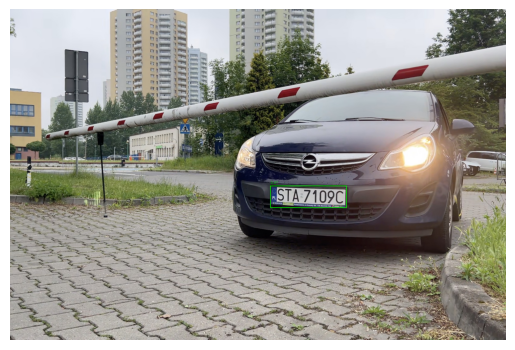

Przycięcie obrazu do wykrytej tablicy


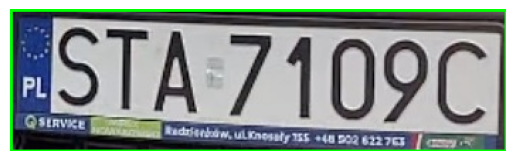

Ucięcie obrazu z lewej strony i segmentacja znaków


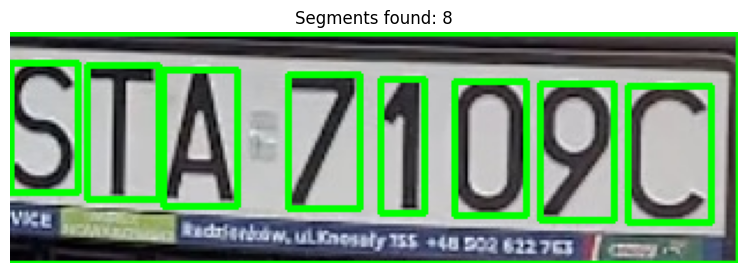

Processing znaków do OCR


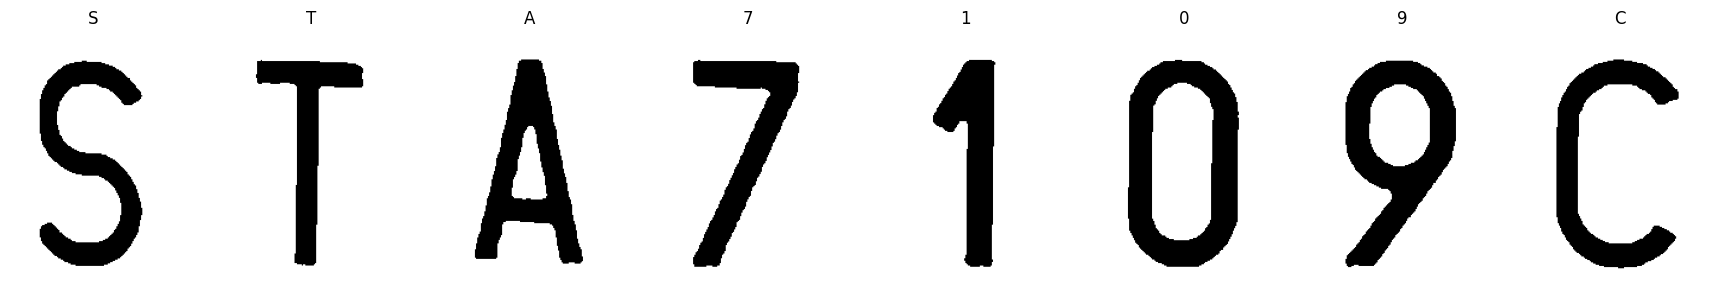

In [45]:
model = YOLO(MODEL_PATH)
img_path = "dataset/poland-vehicle-license-plate-dataset/photos/152.jpg"

results = model(img_path)
boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
scores = results[0].boxes.conf.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

img = cv2.imread(img_path)
for i, (x1, y1, x2, y2) in enumerate(boxes):
    cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)
    cv2.putText(img, f"{scores[i]:.2f}", (int(x1), int(y1)-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    print("-----------------------")
    print("Wykrycie tablicy (YOLO)")
    plt.axis("off")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()
    print("Przycięcie obrazu do wykrytej tablicy")
    crop = img[y1:y2, x1:x2]
    plt.axis("off")
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.show()
    print("Ucięcie obrazu z lewej strony i segmentacja znaków")
    ocr_plate_segmented(crop, debug=True)
    print("Processing znaków do OCR")
    show_char_ocr(crop)


###Eksportowanie modelu YOLO

In [16]:
#!zip plate_model_s runs/detect/plate_detector_s/*

In [17]:
#from google.colab import files
#files.download('plate_model_s.zip')